Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0390
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3207e-04
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.6086e-04
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.7437e-04
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.0980e-04
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.5766e-04
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.1351e-04
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9233e-04
Epoch 9/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.1214e-04
Epoch 10/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7621e-04
Epoch 11/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5051e-04
Epoch 12/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1593e-04
Epoch 13/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.3462e-04
Epoch 14/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.8603e-04
Epoch 15/30
54/54 ━

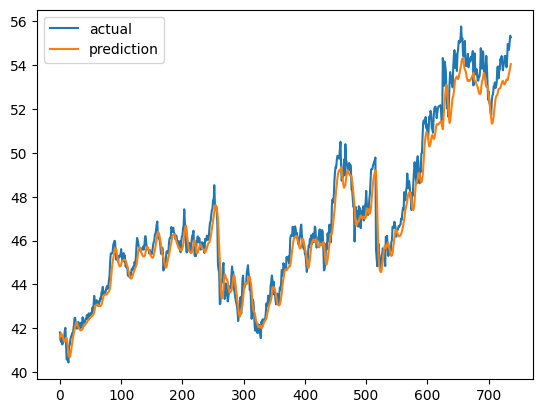

In [ ]:
#pip install finance_datareader
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt

# 2010~2019년 KO(코카콜라) 주가 데이터 불러오기
stock = fdr.DataReader('KO', '2010-01-01', '2019-12-31')
prices = np.asarray(stock['Close'], dtype='float32')

# 종가를 0~1로 정규화
y = (prices - min(prices)) / (max(prices) - min(prices))

window_size = 60
data_length = len(y) - window_size

# 입력(x_data): window_size만큼의 과거 데이터, 출력(y_data): 다음 시점의 값
y_data = np.zeros(data_length, dtype='float32')
x_data = np.zeros((data_length, window_size, 1), dtype='float32')
for i in range(data_length):
    y_data[i] = y[i + window_size]
    x_data[i] = y[i:i + window_size].reshape(window_size, 1) # 첫 번째 LSTM 층만 입력 데이터의 형태를 명확히 명시해줘야함.

from sklearn.model_selection import train_test_split
# 시계열 예측이므로 shuffle=False로 분할
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.3, shuffle=False
)

from tensorflow import keras
# LSTM 2층 + Dense 1층 시계열 예측 모델
model = keras.Sequential([
    keras.layers.LSTM(30, return_sequences=True),
    # keras.layers.LSTM(30, return_sequences=True, input_shape=(window_size, 1)),
    # 코드삭제이유  두 번째(이후) LSTM 층은 앞 층의 출력 shape을 자동으로 인식하기 때문에 첫 번째 층에서 입력 shape을 명시해줄 필요가 없음.
    keras.layers.LSTM(30),
    keras.layers.Dense(1, activation=None)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=30)

# 예측 (정규화된 값 → 실제 가격으로 역변환)
pred = model.predict(x_test)
pred_price = (max(prices) - min(prices)) * pred + min(prices)
target_price = (max(prices) - min(prices)) * y_test + min(prices)

# 실제값과 예측값 시각화
plt.figure()
plt.plot(target_price, label='actual')
plt.plot(pred_price, label='prediction')
plt.legend()
plt.show()


**FinanceDataReader 패키지를 이용하여 현대차(코스피 코드 '005380')의 2021년 1월 1일부터 12월 31일까지의 주가를 읽어들이고, 여기서 직전 4일간의 종가 및 거래량을 바탕으로 다음날 주가를 예측하기 위한 구조로 학습데이터를 구성하는 프로그램을 작성하시오.**

In [3]:
import FinanceDataReader as fdr
import numpy as np

# 2021년 12월 한 달간 현대차(005380) 주가 데이터 불러오기
stock = fdr.DataReader('005380', '2021-12-01', '2021-12-31')
prices = np.asarray(stock['Close'], dtype='float32')
volume = np.asarray(stock['Volume'], dtype='float32')

window_size = 4
data_length = len(stock) - window_size

# y_data: 예측 대상(미래의 종가), x_data: 과거 window_size일의 종가와 거래량
y_data = np.zeros(data_length, dtype='float32')
x_data = np.zeros((data_length, window_size, 2), dtype='float32')  # 2개 특성(Close, Volume)

for i in range(data_length):
    # x_data[i]: i~i+window_size-1까지의 종가와 거래량
    x_data[i] = stock.iloc[i:i+window_size][['Close', 'Volume']]
    # y_data[i]: i+window_size번째의 종가(미래 예측값)
    y_data[i] = stock.iloc[i+window_size]['Close']

# 데이터 확인용 출력
for i in range(data_length):
    print(stock.index[i])         # 날짜(인덱스)
    print('Feature = ')
    print(x_data[i])              # 입력 특성(과거 window_size일의 종가, 거래량)
    print('Target = ', y_data[i]) # 예측 대상(미래 종가)
    print()

2021-12-01 00:00:00
Feature = 
[[201000. 741594.]
 [205500. 782923.]
 [206000. 514358.]
 [206500. 503652.]]
Target =  207500.0

2021-12-02 00:00:00
Feature = 
[[205500. 782923.]
 [206000. 514358.]
 [206500. 503652.]
 [207500. 501624.]]
Target =  207500.0

2021-12-03 00:00:00
Feature = 
[[206000. 514358.]
 [206500. 503652.]
 [207500. 501624.]
 [207500. 502904.]]
Target =  207000.0

2021-12-06 00:00:00
Feature = 
[[206500. 503652.]
 [207500. 501624.]
 [207500. 502904.]
 [207000. 775215.]]
Target =  207500.0

2021-12-07 00:00:00
Feature = 
[[207500. 501624.]
 [207500. 502904.]
 [207000. 775215.]
 [207500. 443350.]]
Target =  209000.0

2021-12-08 00:00:00
Feature = 
[[207500. 502904.]
 [207000. 775215.]
 [207500. 443350.]
 [209000. 877690.]]
Target =  211000.0

2021-12-09 00:00:00
Feature = 
[[207000. 775215.]
 [207500. 443350.]
 [209000. 877690.]
 [211000. 499536.]]
Target =  209000.0

2021-12-10 00:00:00
Feature = 
[[207500. 443350.]
 [209000. 877690.]
 [211000. 499536.]
 [209000. 436219

**위의 실습예제 13-1과 예제코드 ex13-1을 활용하여, 2011년 1월 1일부터 2021년 12월 31일까지의 직전 60일간 (종가, 거래량)과 다음날 주가(종가)의의 관계를 학습하고, 이를 이용해 2011년 1월 1일부터 2021년 12월 31일까지 다음날 주가를 예측한 결과를 그래프로 나타내시오.**


**실습예제 13-1의 코드에서 입력 기간 window_size를 60으로 수정하고, 이를 이용해 예측을 수행하였다.**

Epoch 1/30


/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0797
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0018
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0010
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.2569e-04
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.0853e-04
Epoch 9/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.1402e-04
Epoch 10/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.9001e-04
Epoch 11/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.4845e-04
Epoch 12/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.1786e-04
Epoch 13/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.9577e-04
Epoch 14/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.8745e-04
Epoch 15/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/ste

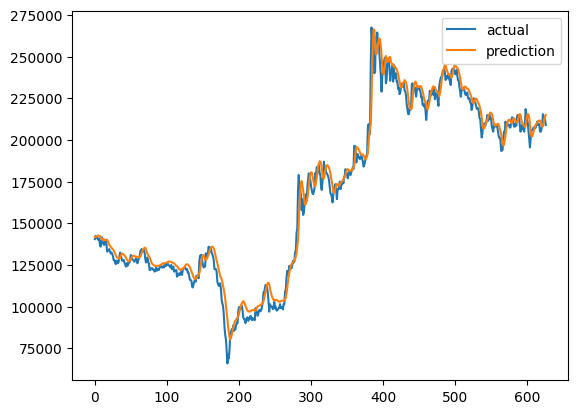

In [5]:
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# 2011~2021년 현대차(005380) 주가 데이터 불러오기
stock = fdr.DataReader('005380', '2011-01-01', '2021-12-31')
prices = np.asarray(stock['Close'], dtype='float32')
volume = np.asarray(stock['Volume'], dtype='float32')

# 종가와 거래량의 최소/최대값 계산 (정규화용)
minPrice = np.min(stock['Close'])
maxPrice = np.max(stock['Close'])
minVolume = np.min(stock['Volume'])
maxVolume = np.max(stock['Volume'])

# 종가와 거래량을 0~1로 정규화
stock['Close'] = (stock['Close'] - minPrice) / (maxPrice - minPrice)
stock['Volume'] = (stock['Volume'] - minVolume) / (maxVolume - minVolume)

window_size = 60
data_length = len(stock) - window_size

# y_data: 예측 대상(미래의 종가), x_data: 과거 window_size일의 종가와 거래량
y_data = np.zeros(data_length, dtype='float32')
x_data = np.zeros((data_length, window_size, 2), dtype='float32')  # 2개 특성(Close, Volume)

for i in range(data_length):
    y_data[i] = stock.iloc[i + window_size]['Close']
    x_data[i] = stock.iloc[i:i + window_size][['Close', 'Volume']]

from sklearn.model_selection import train_test_split
# 시계열 예측이므로 shuffle=False로 분할
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.3, shuffle=False
)

from tensorflow import keras
# LSTM 2층 + Dense 1층 시계열 예측 모델
model = keras.Sequential([
    keras.layers.LSTM(60, return_sequences=True, input_shape=(window_size, 2)),
    keras.layers.LSTM(60, input_shape=(window_size, 2)),
    keras.layers.Dense(1, activation=None)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=30)

# 예측 (정규화된 값 → 실제 가격으로 역변환)
pred = model.predict(x_test)
pred_price = pred * (maxPrice - minPrice) + minPrice
target_price = y_test * (maxPrice - minPrice) + minPrice

# 실제값과 예측값 시각화
plt.figure()
plt.plot(target_price, label='actual')
plt.plot(pred_price, label='prediction')
plt.legend()
plt.show()